## Cell 1: Cài Đặt Thư Viện

In [3]:

import os, math, warnings, time
import numpy as np
import pandas as pd
import snowflake.connector
import matplotlib.pyplot as plt
from IPython.display import display
warnings.filterwarnings('ignore')



## Cell 2: Config


In [ ]:
SOURCE_TABLE = 'BIGDATA_DB.STAGING.USER_PORTFOLIOS'
OUTPUT_TABLE = 'BIGDATA_DB.STAGING.ALS_TOKEN_RECOMMENDATIONS'
# Filter
MIN_USER_TOKENS   = 1    
MIN_TOKEN_HOLDERS = 30   
# ALS params
RANK      = 4     
ALPHA     = 10.0  
REG_PARAM = 0.20  
MAX_ITER  = 15    
TOP_N     = 5     
HOLDOUT_N = 1     
SEED      = 42

np.random.seed(SEED)
print('Config OK')


Config OK


## Cell 3: Kết Nối Snowflake

In [ ]:
# Ket noi Snowflake bang snowflake.connector
conn = snowflake.connector.connect(
    user      = 'TÊN_USER',
    password  = 'password của bạn',
    account   = 'TÊN_ACCOUNT',
    database  = 'database',
    schema    = 'schema',
    autocommit= True,
)
cur = conn.cursor()

# Kich hoat warehouse
cur.execute('USE WAREHOUSE SYSTEM$STREAMLIT_NOTEBOOK_WH')
print('Warehouse: SYSTEM$STREAMLIT_NOTEBOOK_WH')

# Xac nhan ket noi
cur.execute('SELECT CURRENT_USER(), CURRENT_DATABASE(), CURRENT_SCHEMA(), CURRENT_WAREHOUSE()')
row = cur.fetchone()
print(f'User     : {row[0]}')
print(f'Database : {row[1]}')
print(f'Schema   : {row[2]}')
print(f'Warehouse: {row[3]}')
print('Ket noi Snowflake thanh cong!')


Warehouse: SYSTEM$STREAMLIT_NOTEBOOK_WH
User     : HUYDAN
Database : BIGDATA_DB
Schema   : STAGING
Warehouse: SYSTEM$STREAMLIT_NOTEBOOK_WH
Ket noi Snowflake thanh cong!


## Cell 4: Load USER_PORTFOLIOS


In [ ]:
# Load USER_PORTFOLIOS qua snowflake.connector
print('Loading USER_PORTFOLIOS...')
t0 = time.time()

cur.execute(f'''
    SELECT USER_ID, TOKEN_ID, TX_COUNT
    FROM {SOURCE_TABLE}
    WHERE USER_ID  IS NOT NULL
      AND TOKEN_ID IS NOT NULL
      AND TX_COUNT > 0
''')
rows = cur.fetchall()
cols = [d[0].lower() for d in cur.description]
pdf  = pd.DataFrame(rows, columns=cols)
pdf['tx_count'] = pd.to_numeric(pdf['tx_count'], errors='coerce').fillna(0.0)
pdf['user_id']  = pdf['user_id'].astype(str)
pdf['token_id'] = pdf['token_id'].astype(str)
cur.close()

print(f'Loaded trong {time.time()-t0:.1f}s')
print(f'Rows  : {len(pdf):,}')
print(f'Users : {pdf["user_id"].nunique():,}')
print(f'Tokens: {pdf["token_id"].nunique():,}')
display(pdf.head(5))


Loading USER_PORTFOLIOS...
Loaded trong 12.4s
Rows  : 2,274,180
Users : 611,253
Tokens: 381


,user_id,token_id,tx_count
0,11459558,37651,9
1,13824590,54168,1
2,13824590,130149,1
3,28247232,9179,1
4,12703125,130149,1


## Cell 5: Tính Interaction Strength


In [ ]:
# Gộp lại nếu có trùng (user_id, token_id)
pdf = (
    pdf.groupby(['user_id', 'token_id'], as_index=False)
       .agg(tx_count=('tx_count', 'sum'))
)

# interaction_strength = log(TX_COUNT + 1)
log_tx = np.log1p(pdf['tx_count'].clip(lower=0))
max_val = log_tx.max()
pdf['interaction_strength'] = log_tx / max_val if max_val > 0 else log_tx

print('interaction_strength stats:')
print(pdf['interaction_strength'].describe())
pdf[['user_id','token_id','tx_count','interaction_strength']].head(8)


interaction_strength stats:
count    2.273987e+06
mean     1.800446e-01
std      1.118004e-01
min      7.530753e-02
25%      7.530753e-02
50%      1.506151e-01
75%      2.786710e-01
max      1.000000e+00
Name: interaction_strength, dtype: float64


,user_id,token_id,tx_count,interaction_strength
0,10,130149,1,0.075308
1,10,147692,19,0.325474
2,10,26553,3,0.150615
3,10,31100,1,0.075308
4,10,97321,13,0.286722
5,1000003,126457,1,0.075308
6,1000003,130149,1,0.075308
7,1000003,64145,3,0.150615


## Cell 6: Filter & Encode Index


In [ ]:

# 3. LỌC DỮ LIỆU & ENCODE INDEX (CHUẨN HÓA THEO GCN)
print('Đang lọc dữ liệu...')

# 1. Đặt lại mốc lọc giống hệt GCN
MIN_USER_TOKENS = 3
MIN_TOKEN_HOLDERS = 2

# 2. Sử dụng transform để đếm và lọc cực kỳ tốc độ (không dùng merge)
user_counts = pdf.groupby("user_id")["token_id"].transform('nunique')
token_counts = pdf.groupby("token_id")["user_id"].transform('nunique')
pdf = pdf[(user_counts >= MIN_USER_TOKENS) & (token_counts >= MIN_TOKEN_HOLDERS)].copy()

# 3. Encode ID sang dạng Index bắt đầu từ 0
user_ids  = sorted(pdf['user_id'].unique())
token_ids = sorted(pdf['token_id'].unique())

user_to_idx  = {u: i for i, u in enumerate(user_ids)}
token_to_idx = {t: i for i, t in enumerate(token_ids)}
idx_to_user  = dict(enumerate(user_ids))
idx_to_token = dict(enumerate(token_ids))

pdf['u'] = pdf['user_id'].map(user_to_idx)
pdf['i'] = pdf['token_id'].map(token_to_idx)

n_users  = len(user_ids)
n_tokens = len(token_ids)
sparsity = (1 - len(pdf) / (n_users * n_tokens)) * 100

print(f'=== KẾT QUẢ SAU KHI LỌC (Khớp 100% với GCN) ===')
print(f'Interactions: {len(pdf):,}')
print(f'Users       : {n_users:,}')
print(f'Tokens      : {n_tokens:,}')
print(f'Sparsity    : {sparsity:.4f}%')
print(f'Avg tok/user: {len(pdf)/n_users:.1f}')

Đang lọc dữ liệu...
=== KẾT QUẢ SAU KHI LỌC (Khớp 100% với GCN) ===
Interactions: 2,009,514
Users       : 464,423
Tokens      : 381
Sparsity    : 98.8643%
Avg tok/user: 4.3


In [9]:
user_token_count  = pdf.groupby('user_id')['token_id'].nunique().rename('user_token_count')
token_holder_count = pdf.groupby('token_id')['user_id'].nunique().rename('token_holders')

pdf = pdf.merge(user_token_count,  on='user_id')
pdf = pdf.merge(token_holder_count, on='token_id')
pdf = pdf[
    (pdf['user_token_count'] >= MIN_USER_TOKENS)
    & (pdf['token_holders']  >= MIN_TOKEN_HOLDERS)
].copy()

user_ids  = sorted(pdf['user_id'].unique())
token_ids = sorted(pdf['token_id'].unique())

user_to_idx  = {u: i for i, u in enumerate(user_ids)}
token_to_idx = {t: i for i, t in enumerate(token_ids)}
idx_to_user  = {i: u for u, i in user_to_idx.items()}
idx_to_token = {i: t for t, i in token_to_idx.items()}

pdf['u'] = pdf['user_id'].map(user_to_idx)
pdf['i'] = pdf['token_id'].map(token_to_idx)

n_users  = len(user_ids)
n_tokens = len(token_ids)
sparsity = (1 - len(pdf) / (n_users * n_tokens)) * 100

print(f'Interactions: {len(pdf):,}')
print(f'Users       : {n_users:,}')
print(f'Tokens      : {n_tokens:,}')
print(f'Sparsity    : {sparsity:.2f}%')
print(f'Avg tok/user: {len(pdf)/n_users:.1f}')


Interactions: 2,009,514
Users       : 464,423
Tokens      : 381
Sparsity    : 98.86%
Avg tok/user: 4.3


## Cell 7: Holdout Test Split


In [10]:
rng = np.random.default_rng(SEED)
test_indices = []
for _, group in pdf.groupby('u'):
    n_holdout = min(HOLDOUT_N, len(group) - 1)
    if n_holdout > 0:
        chosen = rng.choice(group.index.to_numpy(), size=n_holdout, replace=False)
        test_indices.extend(chosen.tolist())

test_df  = pdf.loc[test_indices].copy()
train_df = pdf.drop(index=test_indices).copy()

print(f'Train interactions: {len(train_df):,}')
print(f'Test  interactions: {len(test_df):,}')
print(f'Test  users       : {test_df["u"].nunique():,}')


Train interactions: 1,545,091
Test  interactions: 464,423
Test  users       : 464,423


## Cell 8: ALS Implicit Feedback


In [11]:
def build_interaction_lists(data, group_col, other_col):
    result = [[] for _ in range(data[group_col].max() + 1)]
    for row in data[[group_col, other_col, 'interaction_strength']].itertuples(index=False):
        result[int(row[0])].append((int(row[1]), float(row[2])))
    return result

user_items = build_interaction_lists(train_df, 'u', 'i')
item_users = build_interaction_lists(train_df, 'i', 'u')

user_factors  = 0.01 * rng.normal(size=(n_users,  RANK))
token_factors = 0.01 * rng.normal(size=(n_tokens, RANK))

def solve_side(target_factors, fixed_factors, interactions):
    gram = fixed_factors.T @ fixed_factors
    eye  = np.eye(RANK)
    for target_id, rows in enumerate(interactions):
        if not rows:
            continue
        A = gram.copy()
        b = np.zeros(RANK)
        for fixed_id, strength in rows:
            y          = fixed_factors[fixed_id]
            confidence = 1.0 + ALPHA * strength
            A += (confidence - 1.0) * np.outer(y, y)
            b += confidence * y
        A += REG_PARAM * eye
        target_factors[target_id] = np.linalg.solve(A, b)
    return target_factors

for step in range(1, MAX_ITER + 1):
    user_factors  = solve_side(user_factors,  token_factors, user_items)
    token_factors = solve_side(token_factors, user_factors,  item_users)
    print(f'ALS iteration {step}/{MAX_ITER} done')

print('Train xong!')


ALS iteration 1/15 done
ALS iteration 2/15 done
ALS iteration 3/15 done
ALS iteration 4/15 done
ALS iteration 5/15 done
ALS iteration 6/15 done
ALS iteration 7/15 done
ALS iteration 8/15 done
ALS iteration 9/15 done
ALS iteration 10/15 done
ALS iteration 11/15 done
ALS iteration 12/15 done
ALS iteration 13/15 done
ALS iteration 14/15 done
ALS iteration 15/15 done
Train xong!


## Cell 9: Đánh giá ALS: NDCG / Hit Rate


KET QUA ALS
  RANK=4  ALPHA=10.0  REG=0.2  ITER=15
  Evaluated on 3,000 users
--------------------------------------------------
  Hit@5         : 0.3500  |##############--------------------------|
  NDCG@5        : 0.2509  |##########------------------------------|
  Hit@10        : 0.3920  |###############-------------------------|
  NDCG@10       : 0.2643  |##########------------------------------|
  Hit@20        : 0.4577  |##################----------------------|
  NDCG@20       : 0.2809  |###########-----------------------------|


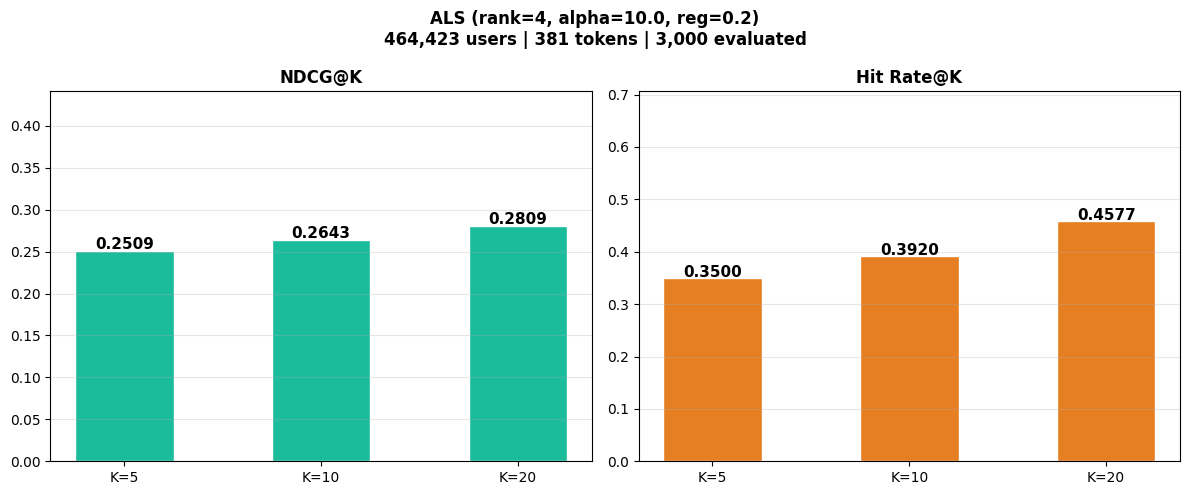

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

def evaluate_als(user_factors, token_factors, test_df, train_df,
                 K_list=[5, 10, 20], sample_n=3000):
    rng_e = np.random.default_rng(42)
    gt    = test_df.groupby('u')['i'].apply(list).to_dict()
    seen  = train_df.groupby('u')['i'].apply(set).to_dict()

    users = list(gt.keys())
    if len(users) > sample_n:
        users = rng_e.choice(users, sample_n, replace=False).tolist()

    # CHỈ GIỮ LẠI HIT VÀ NDCG
    res   = {K: {'hit':[],'ndcg':[]} for K in K_list}
    max_K = max(K_list)
    BATCH = 512

    for start in range(0, len(users), BATCH):
        batch  = users[start:start+BATCH]
        U_b    = user_factors[batch]          
        scores = U_b @ token_factors.T       

        for idx, u in enumerate(batch):
            actual = set(gt[u])
            if not actual:
                continue
            sc = scores[idx].copy()
            for s in seen.get(u, set()):
                sc[s] = -np.inf

            top  = np.argpartition(sc, -max_K)[-max_K:]
            top  = top[np.argsort(sc[top])[::-1]]

            for K in K_list:
                topk  = top[:K].tolist()
                hits  = [1 if t in actual else 0 for t in topk]
                n_rel = len(actual)

                hit   = 1 if sum(hits) > 0 else 0
                dcg   = sum(h/math.log2(i+2) for i,h in enumerate(hits))
                ideal = [1]*min(n_rel,K) + [0]*(K-min(n_rel,K))
                idcg  = sum(h/math.log2(i+2) for i,h in enumerate(ideal))
                ndcg  = dcg/idcg if idcg > 0 else 0

                res[K]['hit'].append(hit)
                res[K]['ndcg'].append(ndcg)

    n   = max(len(res[K_list[0]]['hit']), 1)
    out = {'n_eval': n}
    for K in K_list:
        out[f'Hit@{K}']    = round(np.mean(res[K]['hit']),  4)
        out[f'NDCG@{K}']   = round(np.mean(res[K]['ndcg']), 4)
    return out

KS      = [5, 10, 20]
metrics = evaluate_als(user_factors, token_factors, test_df, train_df, KS)

# Bảng kết quả (Chỉ in Hit và NDCG)
all_keys = [f'{m}@{k}' for k in KS for m in ['Hit','NDCG']]
print('='*50)
print(f'KET QUA ALS')
print(f'  RANK={RANK}  ALPHA={ALPHA}  REG={REG_PARAM}  ITER={MAX_ITER}')
print(f'  Evaluated on {metrics["n_eval"]:,} users')
print('-'*50)
for key in all_keys:
    bar = '#'*int(metrics[key]*40) + '-'*(40-int(metrics[key]*40))
    print(f'  {key:<14}: {metrics[key]:.4f}  |{bar}|')
print('='*50)

# Chart (Đổi thành 1 hàng 2 cột)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'ALS (rank={RANK}, alpha={ALPHA}, reg={REG_PARAM})\n'
             f'{n_users:,} users | {n_tokens} tokens | {metrics["n_eval"]:,} evaluated',
             fontsize=12, fontweight='bold')
axes   = axes.flatten()
colors = ['#1abc9c','#e67e22'] 

for ax, (title, mk, col) in zip(axes, [
    ('NDCG@K',      'NDCG',   colors[0]),
    ('Hit Rate@K',  'Hit',    colors[1]),
]):
    vals = [metrics[f'{mk}@{k}'] for k in KS]
    bars = ax.bar(x, vals, color=col, edgecolor='white', width=0.5)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+.002,
                f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'K={k}' for k in KS])
    ax.set_ylim(0, max(vals)*1.5 + .02)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('als_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 10: Generate Recommendations & Lưu vào Snowflake


In [ ]:
# Tính score cho tất cả user, lấy Top-N
seen_all = pdf.groupby('u')['i'].apply(set).to_dict()

records = []
BATCH   = 1024
all_u   = list(range(n_users))

for start in range(0, len(all_u), BATCH):
    batch  = all_u[start:start+BATCH]
    scores = user_factors[batch] @ token_factors.T
    for idx, u in enumerate(batch):
        sc = scores[idx].copy()
        for s in seen_all.get(u, set()):
            sc[s] = -np.inf
        top = np.argsort(sc)[::-1][:TOP_N]
        for rank, t in enumerate(top, start=1):
            records.append({
                'user_id':   idx_to_user[u],
                'token_id':  idx_to_token[int(t)],
                'rank':      rank,
                'als_score': float(sc[t]),
            })

df_out = pd.DataFrame(records)
print(f'Recommendations: {len(df_out):,} rows')
print(f'Users co goi y : {df_out["user_id"].nunique():,}')
df_out.head(10)


Recommendations: 2,322,115 rows
Users co goi y : 464,423


,user_id,token_id,rank,als_score
0,10,148342,1,0.597575
1,10,55220,2,0.446738
2,10,54168,3,0.127390
3,10,61519,4,0.071876
4,10,10410,5,0.070057
5,1000003,23420,1,0.249230
6,1000003,94167,2,0.041775
7,1000003,76963,3,0.040204
8,1000003,161768,4,0.039919
9,1000003,94800,5,0.039013


In [ ]:

cur2 = conn.cursor()

# Tạo bảng
cur2.execute(f'''
    CREATE TABLE IF NOT EXISTS {OUTPUT_TABLE} (
        USER_ID   VARCHAR,
        TOKEN_ID  VARCHAR,
        RANK      INT,
        ALS_SCORE FLOAT
    )
''')
cur2.execute(f'TRUNCATE TABLE IF EXISTS {OUTPUT_TABLE}')
# Insert theo batch
WRITE_BATCH = 5000
rows_out = [
    (str(r['user_id']), str(r['token_id']), int(r['rank']), float(r['als_score']))
    for _, r in df_out.iterrows()
]
for start in range(0, len(rows_out), WRITE_BATCH):
    batch = rows_out[start:start+WRITE_BATCH]
    cur2.executemany(
        f'INSERT INTO {OUTPUT_TABLE} (USER_ID, TOKEN_ID, RANK, ALS_SCORE) VALUES (%s,%s,%s,%s)',
        batch
    )

cur2.close()
conn.close()
print(f'Da ghi {len(rows_out):,} rows vao {OUTPUT_TABLE}')
print('Dong ket noi Snowflake.')


Da ghi 2,322,115 rows vao BIGDATA_DB.STAGING.ALS_TOKEN_RECOMMENDATIONS
Dong ket noi Snowflake.
